# BABA NN

In [2]:
import numpy as np
import tensorflow as tf
print(tf.__version__) 
from matplotlib import pyplot as plt
import pandas as pd

2.21.0


In [13]:
DATA_DIR = "../data"

BATCH_SIZE = 32

### Build model function

In [111]:
def build_model(config_size, hidden_nodes):
    l2 = 1e-4  # regularization strength λ
    initializer = tf.keras.initializers.RandomNormal(mean=0.0, stddev=1.0)
    x = tf.keras.Input((config_size,))
    y = tf.keras.layers.Dense(hidden_nodes, activation='sigmoid', kernel_initializer=initializer, kernel_regularizer=tf.keras.regularizers.l2(l2))(x)
    z = tf.keras.layers.Dense(1, activation='sigmoid')(y)
    model = tf.keras.Model(inputs=x, outputs=z)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.summary()
    return model

### NN with 3 nodes 1 output

In [112]:
data = np.load("../data/L30_ising.npz")
"""split data into input and output"""
T = data["temperatures"]
T_c = 2 / np.log(1 + np.sqrt(2))        
labels = (T > T_c).astype(int)     #create labels from temperature
configs = data["spins"]

rng = np.random.default_rng(seed=42)
idx = np.arange(len(T))
rng.shuffle(idx)

# Apply the same permutation to all arrays
T = T[idx]
configs = configs[idx]
labels  = labels[idx]

"""split into training, validation and test data"""
train_conf, val_conf, test_conf = np.split(configs, [80000, 90000])
train_label, val_label, test_label = np.split(labels, [80000, 90000])
train_T, val_T, test_T = np.split(T, [80000, 90000])
#print(train_conf.shape)

model3 = build_model(900, 3)

w_init, b_init = model3.layers[1].get_weights()

history = model3.fit(
    train_conf,
    train_label,
    validation_data = (val_conf, val_label),
    batch_size = 256,
    epochs = 200
)

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 900)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 3)              │         2,703 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,707 (10.57 KB)

 Trainable params: 2,707 (10.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - loss: 0.9620 - val_loss: 0.9324
Epoch 2/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step - loss: 0.9088 - val_loss: 0.8877
Epoch 3/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - loss: 0.8674 - val_loss: 0.8497
Epoch 4/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - loss: 0.8317 - val_loss: 0.8166
Epoch 5/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - loss: 0.8001 - val_loss: 0.7859
Epoch 6/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - loss: 0.7707 - val_loss: 0.7580
Epoch 7/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - loss: 0.7426 - val_loss: 0.7310
Epoch 8/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - loss: 0.7142 - val_loss: 0.7021
Epoch 9/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step - loss: 0.6833 - val_loss: 0.6718
Epoch 10/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - loss: 0.6471 - val_loss: 0.6331
Epoch 11/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 488us/step - loss: 0.6029 - val_loss: 0.5854
Epoch 12/200
313/31

evaluation

In [113]:
model3.evaluate(test_conf, test_label, batch_size=100)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 295us/step - loss: 0.1117


0.11170242726802826

### Plots similar to the paper

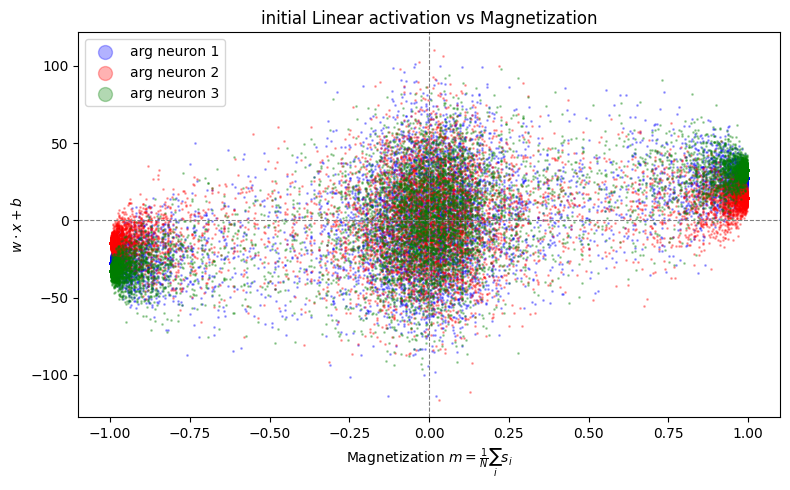

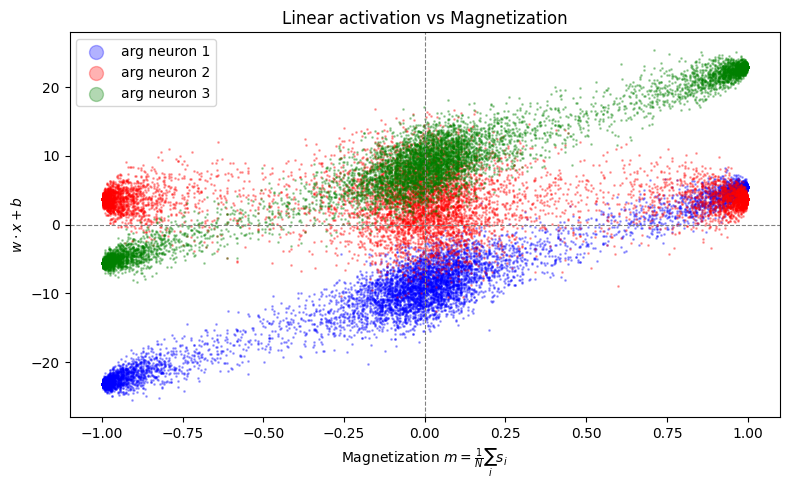

In [114]:
m = test_conf.mean(axis=1)
w, b = model3.layers[1].get_weights()
init_hidden_args = test_conf @ w_init + b_init
hidden_args = test_conf @ w + b
#print(hidden_args[:,0].shape)

plt.figure(figsize=(8, 5))
plt.scatter(m, init_hidden_args[:,0], s=1, alpha=0.3, color = 'b', label = 'arg neuron 1') #c=labels, cmap='coolwarm')
plt.scatter(m, init_hidden_args[:,1], s=1, alpha=0.3, color = 'r', label = 'arg neuron 2')   #c=labels, cmap='coolwarm')
plt.scatter(m, init_hidden_args[:,2], s=1, alpha=0.3, color = 'g', label = 'arg neuron 3')   #c=labels, cmap='coolwarm')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Magnetization $m = \\frac{1}{N}\\sum_i s_i$")
plt.ylabel("$w \\cdot x + b$")
#plt.colorbar(label="Label (0=ordered, 1=disordered)")
plt.legend(markerscale=10)
plt.title("initial Linear activation vs Magnetization")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(m, hidden_args[:,0], s=1, alpha=0.3, color = 'b', label = 'arg neuron 1') #c=labels, cmap='coolwarm')
plt.scatter(m, hidden_args[:,1], s=1, alpha=0.3, color = 'r', label = 'arg neuron 2')   #c=labels, cmap='coolwarm')
plt.scatter(m, hidden_args[:,2], s=1, alpha=0.3, color = 'g', label = 'arg neuron 3')   #c=labels, cmap='coolwarm')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Magnetization $m = \\frac{1}{N}\\sum_i s_i$")
plt.ylabel("$w \\cdot x + b$")
#plt.colorbar(label="Label (0=ordered, 1=disordered)")
plt.legend(markerscale=10)
plt.title("Linear activation vs Magnetization")
plt.tight_layout()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 173us/step


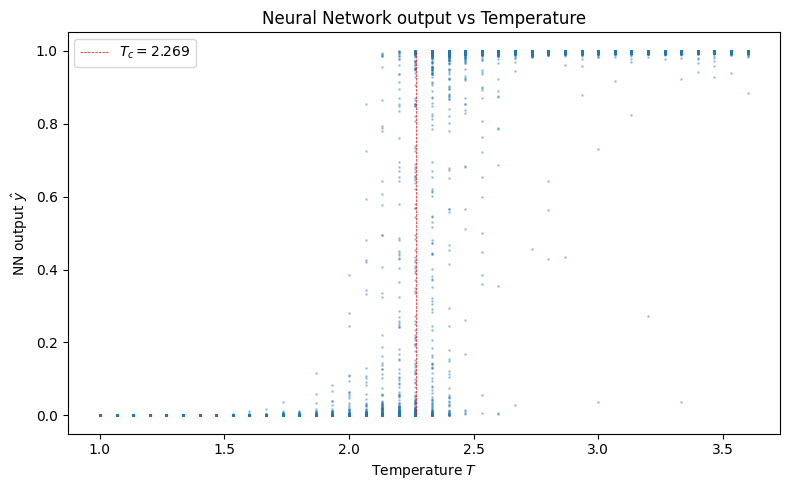

In [116]:
nn_predict = model3.predict(test_conf)

plt.figure(figsize=(8, 5))
plt.vlines(T_c,  ymin = 0, ymax = 1, color='red', linestyle='--', linewidth=0.5, label=f"$T_c = {T_c:.3f}$")
plt.scatter(test_T, nn_predict, s=1, alpha=0.3)
#plt.plot(T, nn_predict)
plt.xlabel("Temperature $T$")
plt.ylabel("NN output $\\hat{y}$")
plt.title("Neural Network output vs Temperature")
plt.legend()
plt.tight_layout()
plt.show()

### NN with 3 nodes 2 outputs

In [117]:
def build_model(config_size, hidden_nodes):
    l2 = 1e-4  # regularization strength λ
    initializer = tf.keras.initializers.RandomNormal(mean=0.0, stddev=1.0)
    x = tf.keras.Input((config_size,))
    y = tf.keras.layers.Dense(hidden_nodes, activation='sigmoid', kernel_initializer=initializer, kernel_regularizer=tf.keras.regularizers.l2(l2))(x)
    z = tf.keras.layers.Dense(2, activation='sigmoid')(y)
    model = tf.keras.Model(inputs=x, outputs=z)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.summary()
    return model

In [121]:
data = np.load("../data/L30_ising.npz")
"""split data into input and output"""
T = data["temperatures"]
T_c = 2 / np.log(1 + np.sqrt(2))        
labels = np.transpose(np.array([(T > T_c).astype(int), (T < T_c).astype(int)]))    #create labels from temperature
configs = data["spins"]

rng = np.random.default_rng(seed=42)
idx = np.arange(len(T))
rng.shuffle(idx)

# Apply the same permutation to all arrays
T = T[idx]
configs = configs[idx]
labels  = labels[idx, :]
print(labels.shape)

"""split into training, validation and test data"""
train_conf, val_conf, test_conf = np.split(configs, [80000, 90000])
train_label, val_label, test_label = np.split(labels, [80000, 90000], axis=0)
train_T, val_T, test_T = np.split(T, [80000, 90000])
#print(train_conf.shape)

model3_2 = build_model(900, 3)

w_init, b_init = model3_2.layers[1].get_weights()

history = model3_2.fit(
    train_conf,
    train_label,
    validation_data = (val_conf, val_label),
    batch_size = 256,
    epochs = 50
)

(100000, 2)


Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 900)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 3)              │         2,703 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 2)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,711 (10.59 KB)

 Trainable params: 2,711 (10.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - loss: 0.9558 - val_loss: 0.9017
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 452us/step - loss: 0.8661 - val_loss: 0.8368
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step - loss: 0.8133 - val_loss: 0.7935
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - loss: 0.7767 - val_loss: 0.7628
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - loss: 0.7490 - val_loss: 0.7380
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 436us/step - loss: 0.7242 - val_loss: 0.7131
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 438us/step - loss: 0.6951 - val_loss: 0.6801
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step - loss: 0.6552 - val_loss: 0.6334
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - loss: 0.6026 - val_loss: 0.5745
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 432us/step - loss: 0.5452 - val_loss: 0.5189
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - loss: 0.4928 - val_loss: 0.4681
Epoch 12/50
313/313 ━━━━━━━━━━

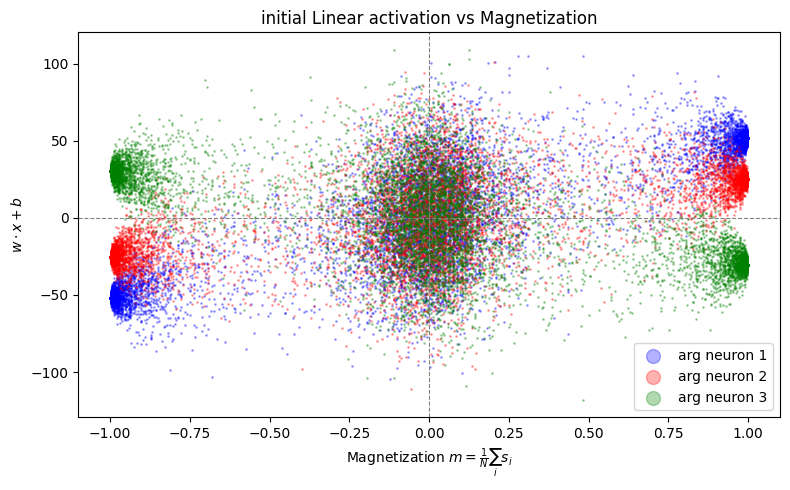

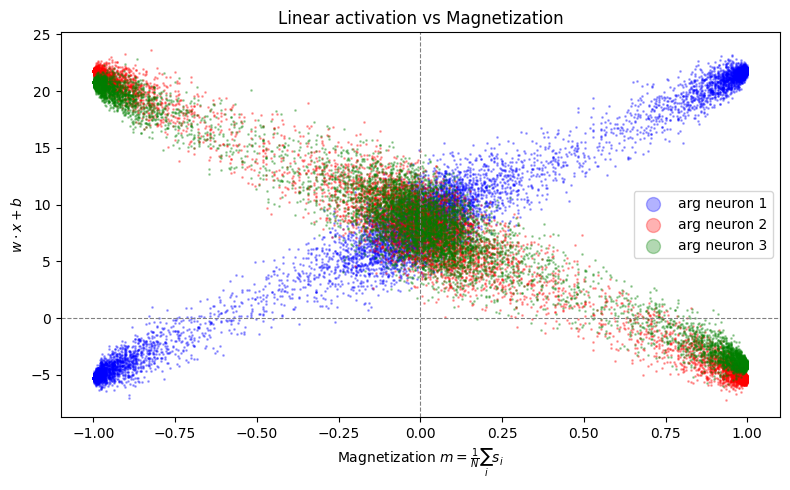

In [122]:
m = test_conf.mean(axis=1)
w, b = model3_2.layers[1].get_weights()
init_hidden_args = test_conf @ w_init + b_init
hidden_args = test_conf @ w + b
#print(hidden_args[:,0].shape)

plt.figure(figsize=(8, 5))
plt.scatter(m, init_hidden_args[:,0], s=1, alpha=0.3, color = 'b', label = 'arg neuron 1') #c=labels, cmap='coolwarm')
plt.scatter(m, init_hidden_args[:,1], s=1, alpha=0.3, color = 'r', label = 'arg neuron 2')   #c=labels, cmap='coolwarm')
plt.scatter(m, init_hidden_args[:,2], s=1, alpha=0.3, color = 'g', label = 'arg neuron 3')   #c=labels, cmap='coolwarm')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Magnetization $m = \\frac{1}{N}\\sum_i s_i$")
plt.ylabel("$w \\cdot x + b$")
#plt.colorbar(label="Label (0=ordered, 1=disordered)")
plt.legend(markerscale=10)
plt.title("initial Linear activation vs Magnetization")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(m, hidden_args[:,0], s=1, alpha=0.3, color = 'b', label = 'arg neuron 1') #c=labels, cmap='coolwarm')
plt.scatter(m, hidden_args[:,1], s=1, alpha=0.3, color = 'r', label = 'arg neuron 2')   #c=labels, cmap='coolwarm')
plt.scatter(m, hidden_args[:,2], s=1, alpha=0.3, color = 'g', label = 'arg neuron 3')   #c=labels, cmap='coolwarm')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Magnetization $m = \\frac{1}{N}\\sum_i s_i$")
plt.ylabel("$w \\cdot x + b$")
#plt.colorbar(label="Label (0=ordered, 1=disordered)")
plt.legend(markerscale=10)
plt.title("Linear activation vs Magnetization")
plt.tight_layout()
plt.show()


  1/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 189us/step
(10000, 2)


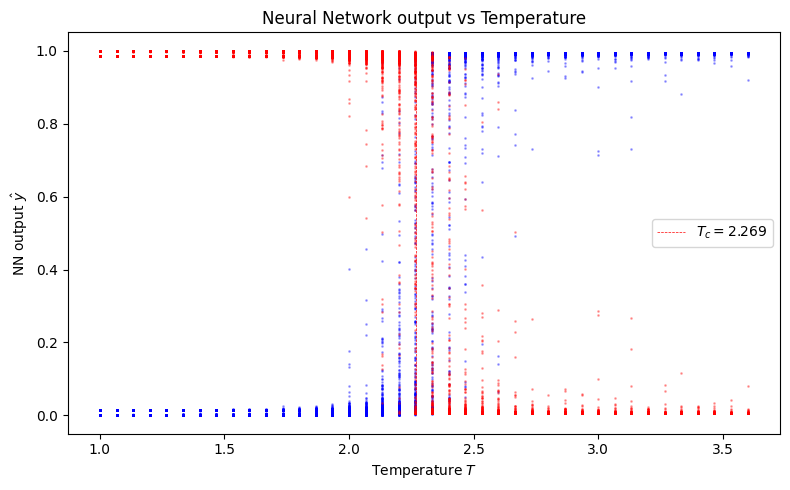

In [124]:
nn_predict = model3.predict(test_conf)
print(nn_predict.shape)

plt.figure(figsize=(8, 5))
plt.vlines(T_c,  ymin = 0, ymax = 1, color='red', linestyle='--', linewidth=0.5, label=f"$T_c = {T_c:.3f}$")
plt.scatter(test_T, nn_predict[:,0], s=1, alpha=0.3, color='b')
#plt.plot(test_T, np.mean(nn_predict))
plt.scatter(test_T, nn_predict[:,1], s=1, alpha=0.3, color='r')
#plt.plot(T, nn_predict)
plt.xlabel("Temperature $T$")
plt.ylabel("NN output $\\hat{y}$")
plt.title("Neural Network output vs Temperature")
plt.legend()
plt.tight_layout()
plt.show()